# Used Car Price Prediction

Objective:
- To predict the fair market price of used vehicle based on vehicle attributes, usage history, market demand, and condition signals

Business Use Cases
- Risk control for under or overpricing
- Trade-in valuation
- Marketplace listing recommendations
- Dealer pricing optimization

ML Framing:
- Type: Supervised Regression
- Target: Price
- Prediction: At listing time

---

## Exploratory Data Analysis (EDA)

1. Data Overview
    - Data Summary
    - Descriptive Statistics

2. Data Quality
    - Missing Data Analysis
    - Duplicate rows

3. Numerical Variable Analysis
    - Distribution Analysis (Histograms)
    - Outlier Detection (Box Plots)
    - Feature-Target Relationships
    - Multicollinearity (Feature correlation, VIF)

4. Categorical Variable Analysis
    - Cardinality
    - Distribution Analysis (Barplot, Boxplot against Target)

#### 1. Data Overview
- Data Summary
- Descriptive Statistics

In [7]:
import warnings
warnings.filterwarnings('ignore')

import os
os.chdir(r'C:\Users\ashle\Project\usecase')

import pandas as pd
from src.functions.eda_analysis import EDA_Analysis as EA
from src.functions.feature_eng import Feature_Engineering as FE
from src.functions.model import ModelTrainer as MT
from src.functions.eval import Model_Interpretability as MI
from src.functions.model_pipeline import ModelPipeline as MP



In [8]:
df = pd.read_csv('data/merc.csv')

In [12]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


Column renaming for ecosystem friendly

In [13]:
df = df.rename(columns={'fuelType': 'fuel_type',
                        'engineSize': 'engine_size',})

In [15]:
df.head()

,model,year,price,transmission,mileage,fuel_type,tax,mpg,engine_size
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


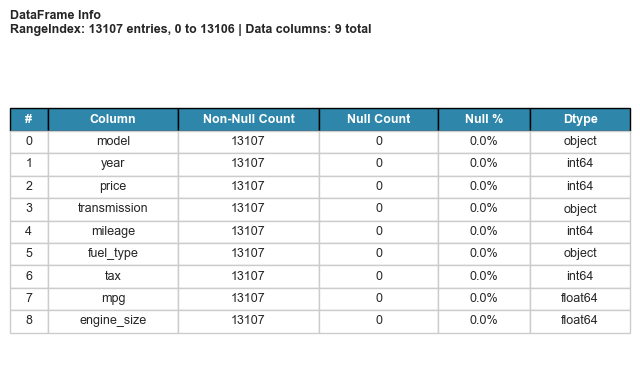

In [16]:
fig = EA.data_info(df)
fig.show()

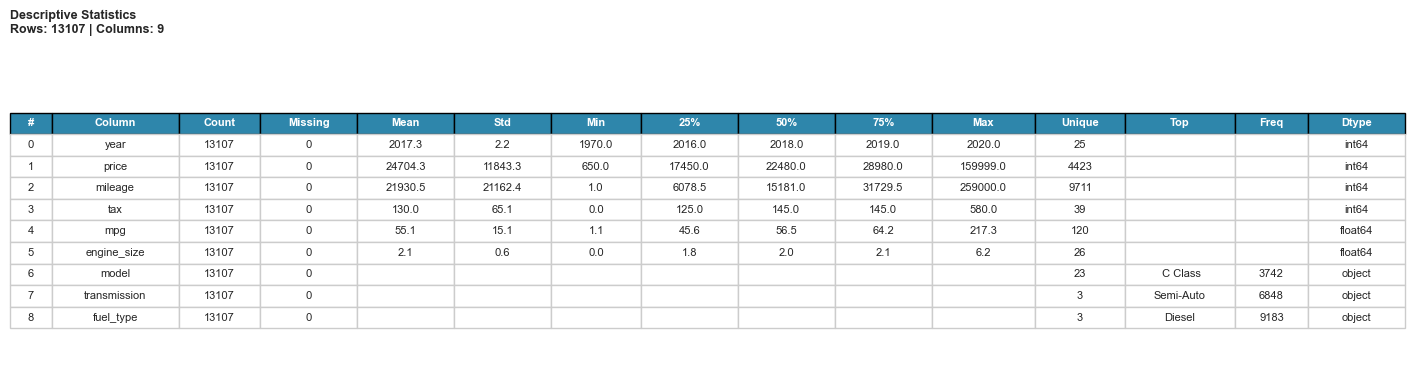

In [17]:
fig = EA.descriptive_stats(df)
fig.show()

There are 5 numerical and 3 categorical features. With target variable (price) to be a numerical type.

#### 2. Data Quality
- Missing Data Analysis

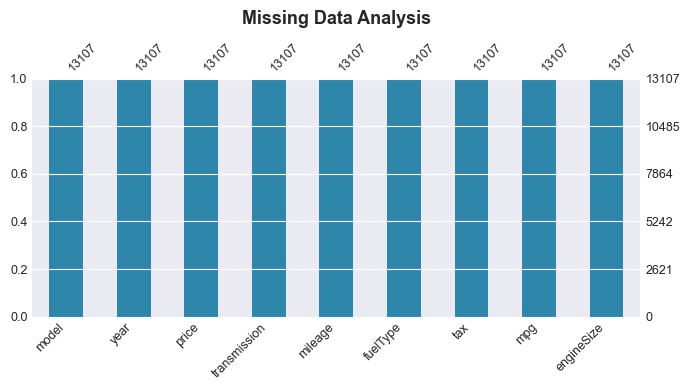

In [11]:
fig = EA.missing_plot(df)
fig.show()

This dataset does not contain any missing value

Create new features: car_age
- It gives better direct representative than car year.
- Drop year column to avoid multicollinearity

In [18]:
df['car_age'] = 2026 - df['year']
df.drop(columns=['year'], inplace=True)

#### 3. Univariate Analysis
- Distribution Analysis (Histograms)
- Outlier Detection (Box Plots)

##### Distribution Analysis
Analyzing the distribution of numerical features to understand their spread, central tendency, and potential skewness.

In [19]:
df.columns.tolist()

['model',
 'price',
 'transmission',
 'mileage',
 'fuel_type',
 'tax',
 'mpg',
 'engine_size',
 'car_age']

In [21]:
num_features = ['mileage', 'tax', 'mpg', 'engine_size', 'car_age']
cat_features = ['model', 'transmission', 'fuel_type']
target = ['price']

Numerical Features Analysis

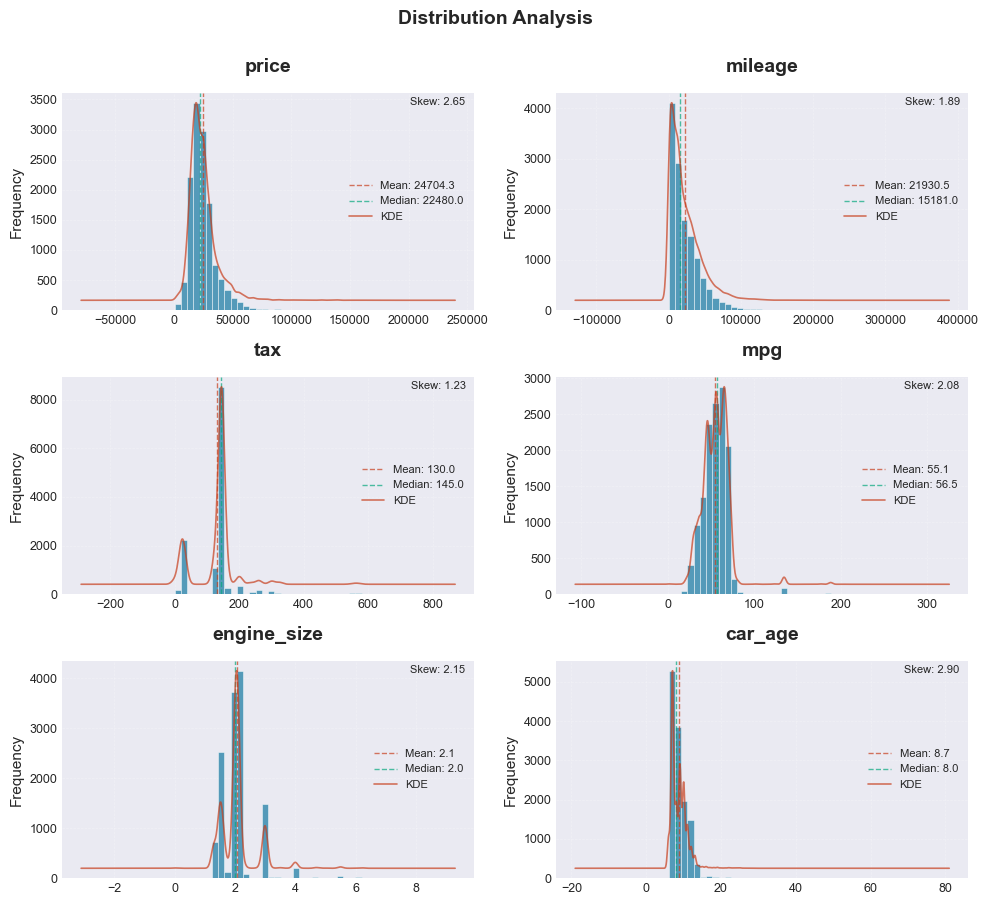

In [24]:
fig = EA.hist_plot(df, variables=target + num_features, combined=True)

1. Overall:
- Mean > Median
- Long right tail
- Positive skewness (>1)

This indicates:
- Non-normal distributions
- Heteroscedasticity risk
- Risk of large values dominating loss (especially for price)

2. price:
- skew = 2.65
- strong right skew
- high-value outliers
- mean much  higher than median
- need transformation
- can cause RMSE to be dominated by expensive car - log transform stabilizes variance

3. mileage:
- skew = 1.89
- highly skewed
- need transformation

4. tax:
- skew = 1.23
- mild skew
- can skip transformation

5. mpg:
- skew = 2.08
- highly skewed
- long tail for very efficient vehicles
- but central mass is compact
- can keep it raw to preserve interpretability
- log transformation may compress meaningful differences

6. engine_size:
- skew = 2.15
- highly skewed
- semi-discrete values (1.5, 2.0, 3.0,...)
- spikes indicate categorical-like numeric
- no log transformation, to preserve magnitude meaning and interpretability

7. car_age:
- skew = 2.90
- highly skewed due to many newer cars and few very old cars
- need transformation

##### Outlier Detection

Box plots to identify outliers and understand the spread of data.

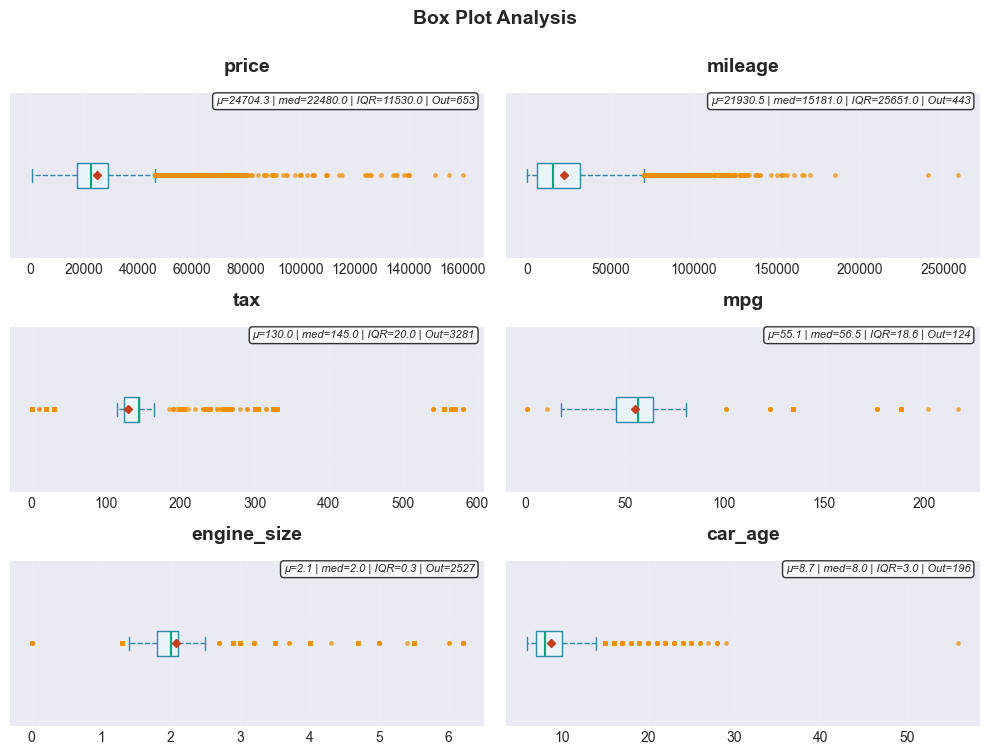

In [25]:
fig = EA.box_plot(df, variables=target + num_features, combined=True)
fig

#### 4. Categorical Feature Analysis

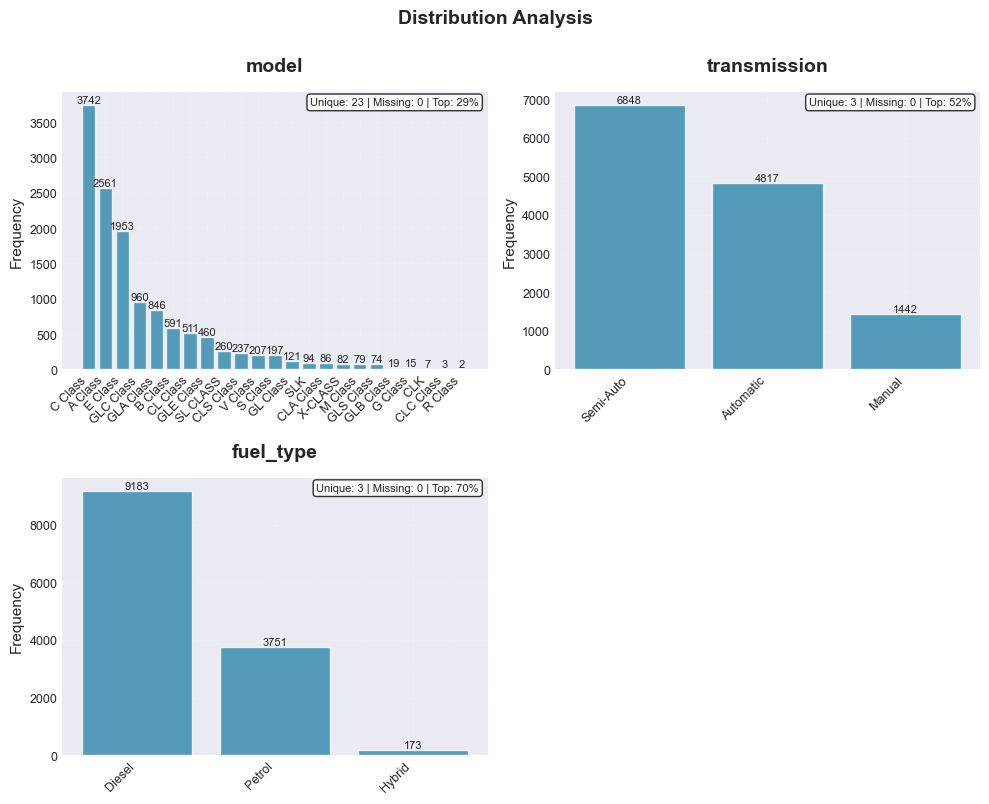

In [26]:
fig = EA.categorical_bar_plot(df, variables=cat_features, combined=True)
fig

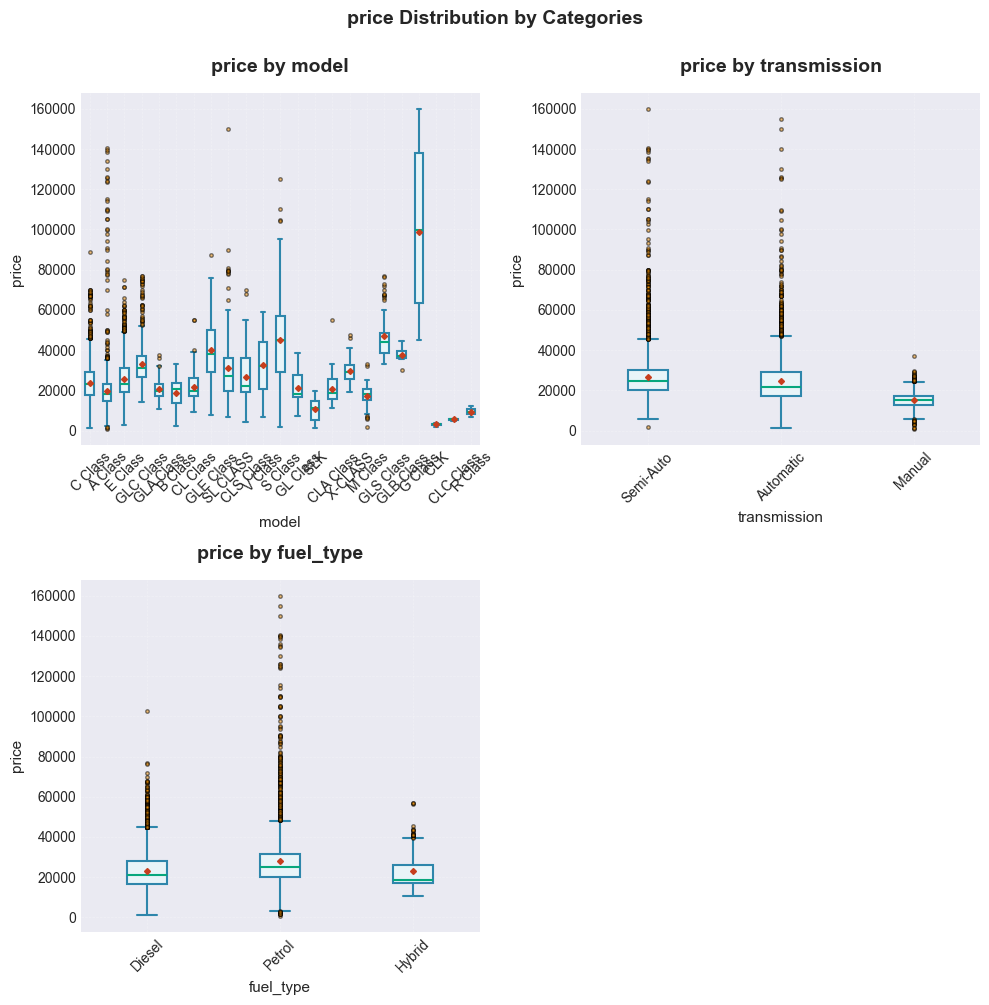

In [27]:
fig = EA.categorical_target_boxplot(data=df, categorical_var=cat_features, target='price', combined=True)
fig

##### Correlation Analysis

Understanding relationships between features using correlation matrix.

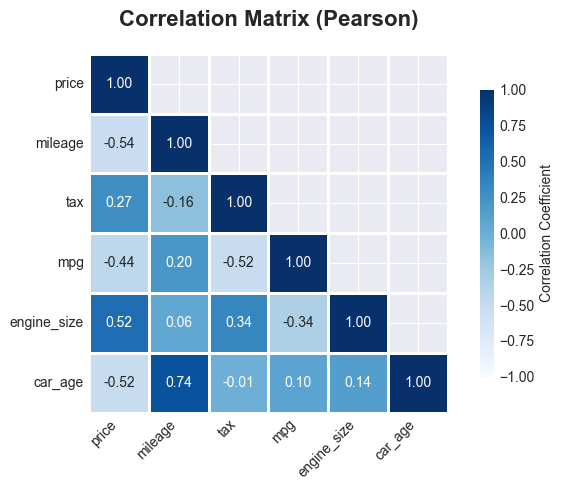

In [29]:
fig = EA.corr_matrix(df, variables=target + num_features, method='pearson')
fig

Dependency Matrix

- To evaluate relationships across continuous, bounded, discrete, and binary variables
- To capture non-linear and asymmetric (directional) dependencies that a correlation matrix cannot represent
- To identify numeric features that are strongly dependent on others, indicating potential redundancy, multicollinearity, or proxy relationships

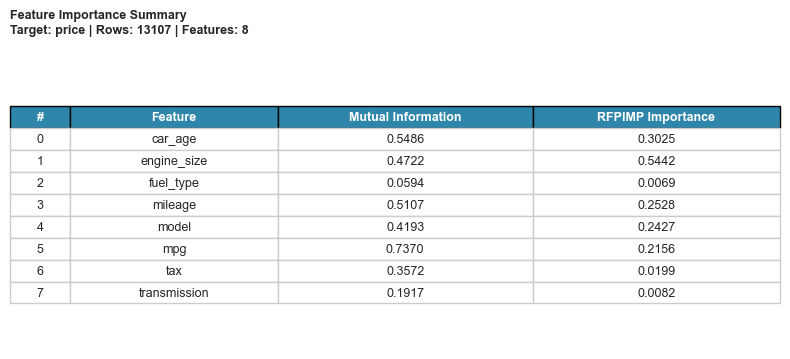

In [30]:
importance_df = EA.importance_with_target(data=df, target='price')

---

## Feature Engineering

1. Handle missing values
2. Apply log feature transformations if |skewness|>=1, then plot the distribution and box plot again
3. Remove or treat outliers if the value is error
4. Plot correlation matrix and dependency importance again
5. Encode categorical variables (one-hot encoding)

1. Missing Value Imputation
- This dataset does not have missing value. Proceed to next step.

2. Apply log feature transformations if |skewness| above 1.5.

In [15]:
df[num_features + target].skew()

mileage        1.887337
tax            1.225503
mpg            2.083267
engine_size    2.147362
car_age        2.899706
price          2.651845
dtype: float64

In [16]:
transformed_features = ['mileage', 'mpg', 'engine_size', 'car_age', 'price']

In [17]:
df_transformed = FE.log_transform_skewed_features(df=df, columns=transformed_features, skew_threshold=0.75)

In [18]:
df_transformed

,model,price,transmission,mileage,fuel_type,tax,mpg,engine_size,car_age
0,SLK,8.556606,Automatic,11.050906,Petrol,325,3.499533,1.029619,3.091042
1,S Class,10.461645,Automatic,10.203629,Hybrid,20,4.133565,1.131402,2.302585
2,SL CLASS,10.818758,Automatic,8.732466,Petrol,555,3.367296,1.871802,2.397895
3,G Class,11.034067,Automatic,9.680406,Petrol,325,3.446808,1.609438,2.397895
4,G Class,11.211131,Automatic,8.294300,Petrol,325,3.437208,1.609438,2.397895
...,...,...,...,...,...,...,...,...,...
13102,C Class,10.491274,Automatic,6.216606,Diesel,145,4.032469,1.098612,1.945910
13103,B Class,10.114559,Automatic,7.824446,Diesel,145,4.032469,1.098612,1.945910
13104,GLC Class,10.341742,Automatic,9.359880,Diesel,145,3.749504,1.131402,2.079442
13105,CLS Class,10.545105,Automatic,7.794411,Diesel,145,3.841601,1.098612,2.079442


In [19]:
df_transformed[num_features + target].skew()

mileage       -1.798431
tax            1.225503
mpg           -0.829651
engine_size    0.857055
car_age        1.004119
price         -0.309170
dtype: float64

Distribution plot before and after transformation

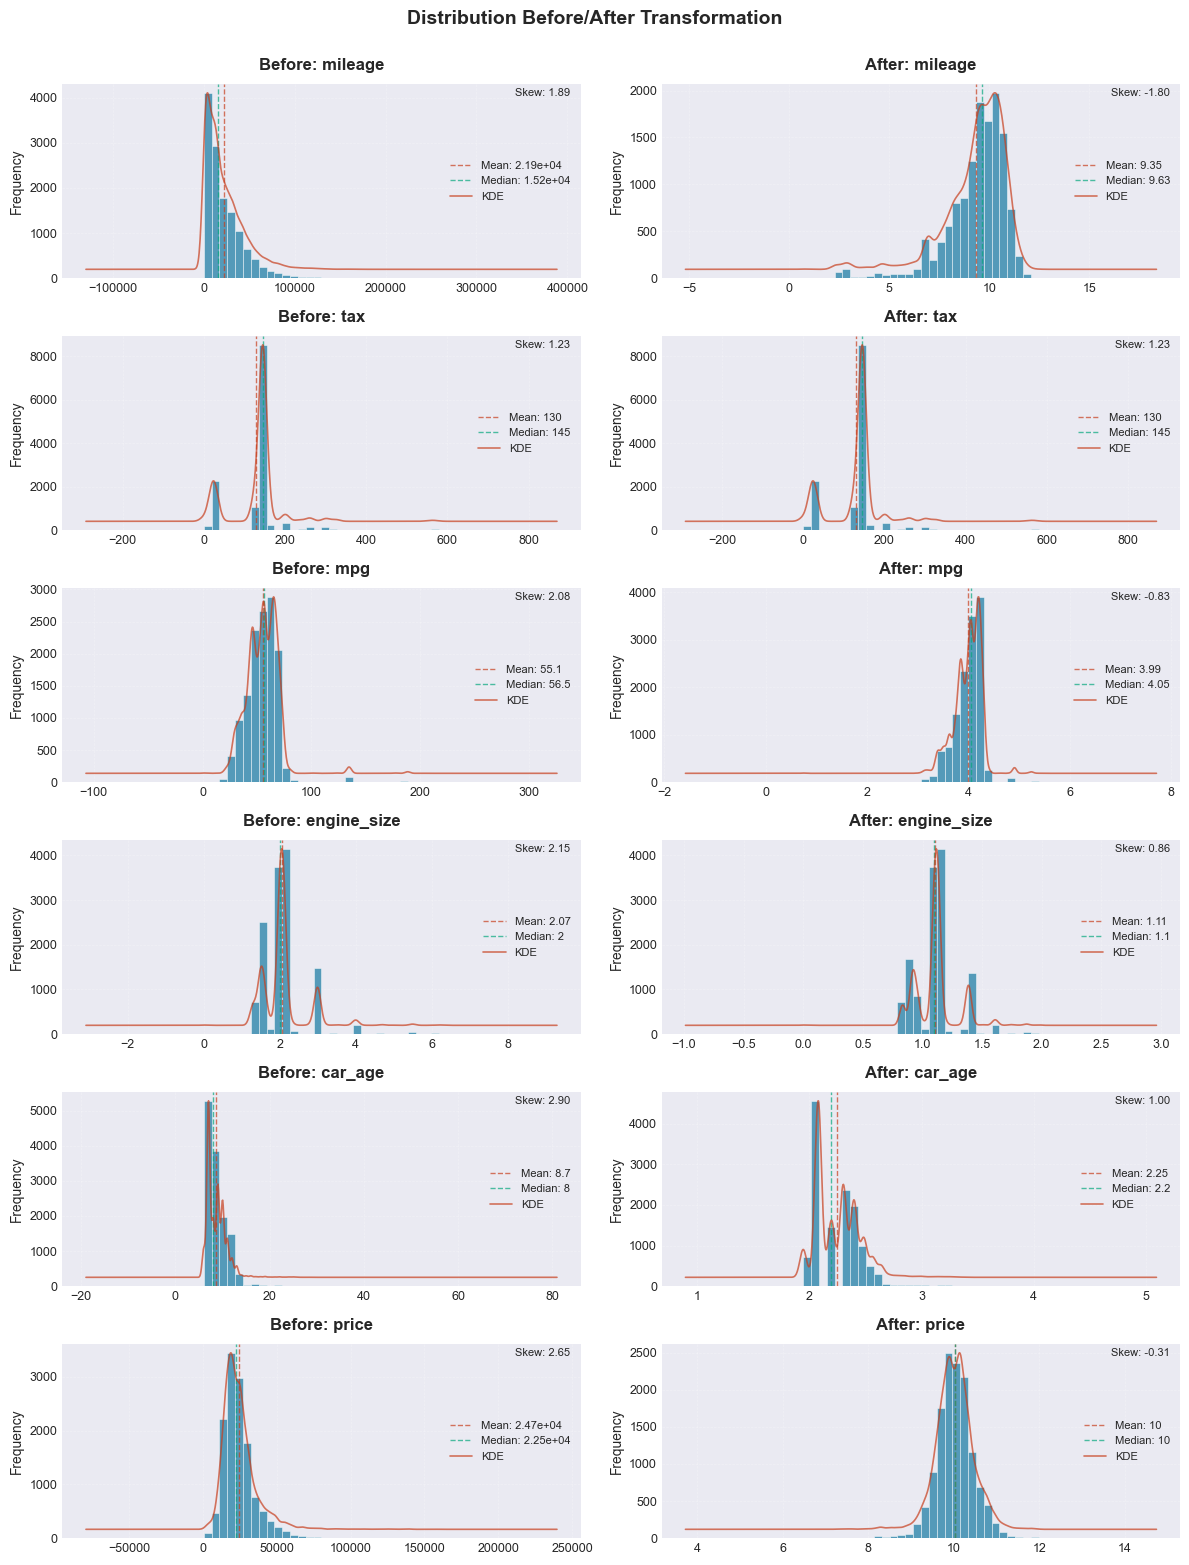

In [20]:
fig = FE.plot_distribution_before_after_log_transform(before_df= df,
                                                      after_df= df_transformed, 
                                                      columns=num_features + target,
                                                      combined=True
                                                      )
      


Boxplot before and after transformation

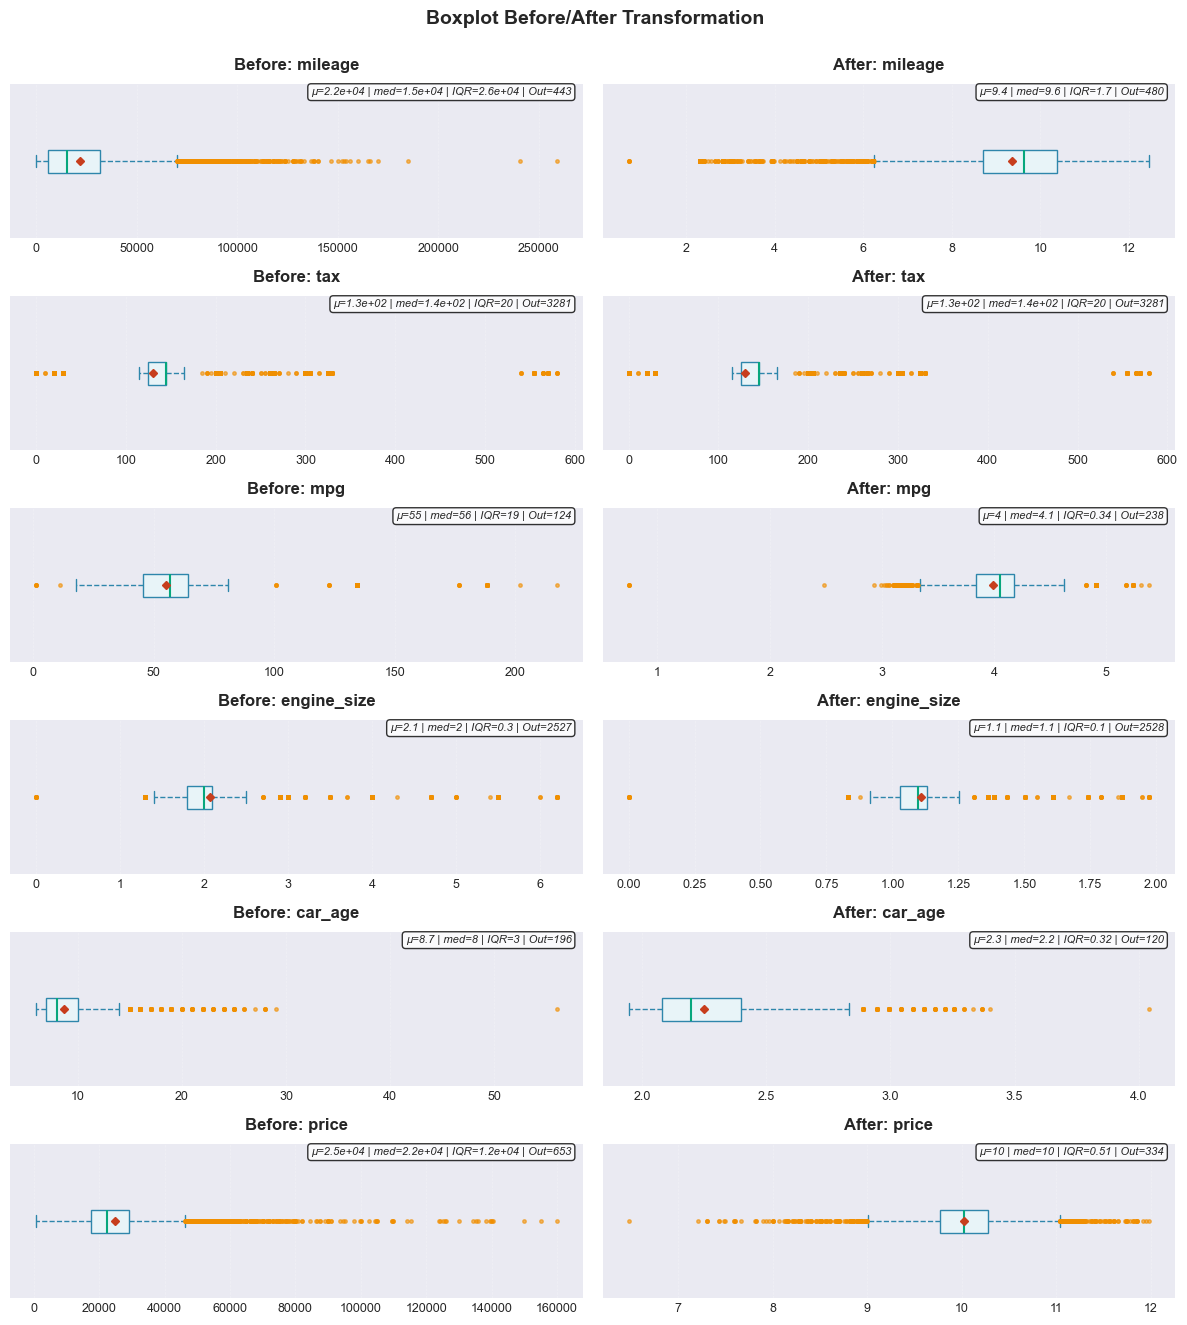

In [21]:
fig = FE.plot_boxplot_before_after_transform(before_df= df,
                                            after_df= df_transformed, 
                                            columns=num_features + target,
                                            combined=True
                                            )

3. Remove or treat outliers if the value is error

Referring to the pre-transformed data. The outliers are not errors. Thus I considered it is safe to keep the data as it is.

4. Plot correlation matrix and dependency importance again

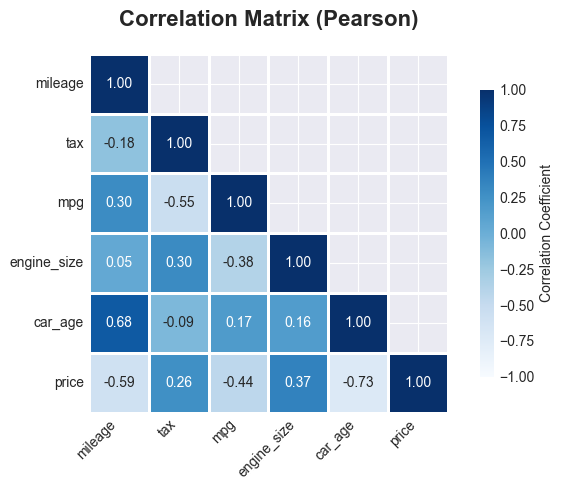

In [22]:
fig = EA.corr_matrix(df_transformed, variables=num_features + target, method='pearson')
fig

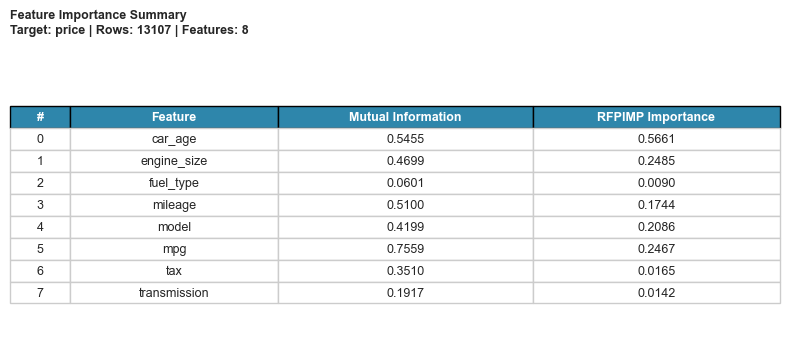

In [23]:
importance_df = EA.importance_with_target(data=df_transformed, target='price')

In [24]:
df_transformed

,model,price,transmission,mileage,fuel_type,tax,mpg,engine_size,car_age
0,SLK,8.556606,Automatic,11.050906,Petrol,325,3.499533,1.029619,3.091042
1,S Class,10.461645,Automatic,10.203629,Hybrid,20,4.133565,1.131402,2.302585
2,SL CLASS,10.818758,Automatic,8.732466,Petrol,555,3.367296,1.871802,2.397895
3,G Class,11.034067,Automatic,9.680406,Petrol,325,3.446808,1.609438,2.397895
4,G Class,11.211131,Automatic,8.294300,Petrol,325,3.437208,1.609438,2.397895
...,...,...,...,...,...,...,...,...,...
13102,C Class,10.491274,Automatic,6.216606,Diesel,145,4.032469,1.098612,1.945910
13103,B Class,10.114559,Automatic,7.824446,Diesel,145,4.032469,1.098612,1.945910
13104,GLC Class,10.341742,Automatic,9.359880,Diesel,145,3.749504,1.131402,2.079442
13105,CLS Class,10.545105,Automatic,7.794411,Diesel,145,3.841601,1.098612,2.079442


5. Encode categorical variables

- One-hot encoding method is selected since there's no clear order pattern to use ordinal encoding

In [25]:
df_enc = FE.encode_categorical_features(df_transformed, columns=["model", "transmission", "fuel_type"], encoding="onehot")
df_enc

,price,mileage,tax,mpg,engine_size,car_age,model_ A Class,model_ B Class,model_ C Class,model_ CL Class,...,model_ SL CLASS,model_ SLK,model_ V Class,model_ X-CLASS,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuel_type_Diesel,fuel_type_Hybrid,fuel_type_Petrol
0,8.556606,11.050906,325,3.499533,1.029619,3.091042,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
1,10.461645,10.203629,20,4.133565,1.131402,2.302585,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,10.818758,8.732466,555,3.367296,1.871802,2.397895,0,0,0,0,...,1,0,0,0,1,0,0,0,0,1
3,11.034067,9.680406,325,3.446808,1.609438,2.397895,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,11.211131,8.294300,325,3.437208,1.609438,2.397895,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13102,10.491274,6.216606,145,4.032469,1.098612,1.945910,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
13103,10.114559,7.824446,145,4.032469,1.098612,1.945910,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
13104,10.341742,9.359880,145,3.749504,1.131402,2.079442,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
13105,10.545105,7.794411,145,3.841601,1.098612,2.079442,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


---

## Model Training

### Train-Test Split

- Split train and test data
- Scale train and transform both train and test

Split train and test data

In [26]:
X = df_enc.drop(columns=['price'])
y = df_enc['price']

In [27]:
X_train, X_test, y_train, y_test = MT.split_train_test(X, y, test_size=0.2, stratify=False)

In [28]:
X_train.describe()

,mileage,tax,mpg,engine_size,car_age,model_ A Class,model_ B Class,model_ C Class,model_ CL Class,model_ CLA Class,...,model_ SL CLASS,model_ SLK,model_ V Class,model_ X-CLASS,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuel_type_Diesel,fuel_type_Hybrid,fuel_type_Petrol
count,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,...,10485.00000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.000000,10485.00000,10485.000000
mean,9.349299,130.085360,3.993529,1.106966,2.250065,0.194278,0.045684,0.287935,0.037482,0.006676,...,0.01917,0.006772,0.015451,0.006009,0.368717,0.109108,0.522175,0.700906,0.01278,0.286314
std,1.504339,65.724144,0.265892,0.166992,0.198825,0.395662,0.208810,0.452822,0.189949,0.081439,...,0.13713,0.082014,0.123343,0.077286,0.482480,0.311790,0.499532,0.457883,0.11233,0.452059
min,0.693147,0.000000,0.741937,0.000000,1.945910,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,8.703673,125.000000,3.841601,1.029619,2.079442,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,9.626745,145.000000,4.051785,1.098612,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,0.000000
75%,10.360374,145.000000,4.177459,1.131402,2.397895,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.00000,1.000000
max,12.464587,580.000000,5.385870,1.974081,4.043051,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [29]:
X_train_s, X_test_s = MT.scale_after_split(X_train, X_test, scaler="standard")

In [30]:
X_train_s.describe()

,mileage,tax,mpg,engine_size,car_age,model_ A Class,model_ B Class,model_ C Class,model_ CL Class,model_ CLA Class,...,model_ SL CLASS,model_ SLK,model_ V Class,model_ X-CLASS,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuel_type_Diesel,fuel_type_Hybrid,fuel_type_Petrol
count,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,...,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04,1.048500e+04
mean,-9.907615e-16,1.199486e-16,-2.154669e-15,8.260864e-16,2.386095e-15,-7.522198e-17,3.523912e-17,4.743728e-18,-2.778469e-17,5.760242e-18,...,2.473515e-17,9.487457e-18,-3.185075e-17,-1.084281e-17,2.168562e-17,4.879263e-17,9.080851e-17,6.505685e-17,8.809781e-18,-6.776755e-19
std,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,...,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00,1.000048e+00
min,-5.754399e+00,-1.979357e+00,-1.222957e+01,-6.629161e+00,-1.529834e+00,-4.910419e-01,-2.187951e-01,-6.358982e-01,-1.973366e-01,-8.198216e-02,...,-1.398032e-01,-8.256964e-02,-1.252722e-01,-7.774899e-02,-7.642487e-01,-3.499583e-01,-1.045378e+00,-1.530827e+00,-1.137788e-01,-6.333846e-01
25%,-4.291968e-01,-7.737800e-02,-5.714168e-01,-4.631952e-01,-8.582001e-01,-4.910419e-01,-2.187951e-01,-6.358982e-01,-1.973366e-01,-8.198216e-02,...,-1.398032e-01,-8.256964e-02,-1.252722e-01,-7.774899e-02,-7.642487e-01,-3.499583e-01,-1.045378e+00,-1.530827e+00,-1.137788e-01,-6.333846e-01
50%,1.844394e-01,2.269387e-01,2.191083e-01,-5.002534e-02,-2.657767e-01,-4.910419e-01,-2.187951e-01,-6.358982e-01,-1.973366e-01,-8.198216e-02,...,-1.398032e-01,-8.256964e-02,-1.252722e-01,-7.774899e-02,-7.642487e-01,-3.499583e-01,9.565921e-01,6.532417e-01,-1.137788e-01,-6.333846e-01
75%,6.721379e-01,2.269387e-01,6.917831e-01,1.463394e-01,7.435538e-01,-4.910419e-01,-2.187951e-01,1.572579e+00,-1.973366e-01,-8.198216e-02,...,-1.398032e-01,-8.256964e-02,-1.252722e-01,-7.774899e-02,1.308475e+00,-3.499583e-01,9.565921e-01,6.532417e-01,-1.137788e-01,1.578820e+00
max,2.070967e+00,6.845827e+00,5.236740e+00,5.192796e+00,9.018335e+00,2.036486e+00,4.570487e+00,1.572579e+00,5.067484e+00,1.219777e+01,...,7.152914e+00,1.211099e+01,7.982620e+00,1.286190e+01,1.308475e+00,2.857483e+00,9.565921e-01,6.532417e-01,8.788986e+00,1.578820e+00


### Model Selection & Training

**Models to evaluate:**
1. Linear Regression (baseline)
2. Random Forest Regressor
3. XGBoost Regressor

**Approach:**
- Cross-validation for robust evaluation
- Hyperparameter tuning using GridSearchCV

In [31]:
model = MT.train_regression(X_train_s, y_train, cv=2)

In [34]:
best_model = MT.select_best(model)

In [44]:
print(best_model.name)
print(best_model.best_params)

xgboost
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'reg_lambda': 1.0, 'subsample': 0.8}


---

## Model Evaluation

### Metrics

**Primary Metrics:**
- **MAE** (Mean Absolute Error): Average absolute difference between predicted and actual values
- **MAPE** (Mean Absolute Percentage Error): Percentage error for interpretability
- **R²** (R-squared): Proportion of variance explained by the model

**Performance Benchmarks:**
- **Excellent**: MAPE < 10%, R² > 90%
- **Good**: MAPE < 15%, R² > 70%
- **Acceptable**: MAPE < 20%, R² > 50%

In [45]:
evaluation_results_all = MT.evaluate_regression_all(results=model, X_train=X_train_s, y_train=y_train, X_test=X_test_s, y_test=y_test)
evaluation_results_all

rmse   mae  mape    r2
model             split                        
random_forest     test   0.11  0.06  0.65  0.94
                  train  0.05  0.03  0.34  0.99
xgboost           test   0.11  0.06  0.61  0.94
                  train  0.05  0.04  0.40  0.98
linear_regression test   0.18  0.12  1.23  0.85
                  train  0.16  0.12  1.18  0.86

In [40]:
# Plot all models at once
fig = MT.plot_actual_vs_predicted_all(
    results=model,
    X_test=X_test_s,
    y_test=y_test,
    title='Model Comparison: Actual vs Predicted',
    xlabel='Actual Price',
    ylabel='Predicted Price'
)
fig.show()

---

## Model Interpretability

### Feature Importance
Understanding which features contribute most to predictions.

### SHAP Analysis
SHAP (SHapley Additive exPlanations) values for detailed model interpretation:

In [ ]:
# fig = MI.shap_summary_plot(
#     model=best_model,
#     X=X_train_s,                 
#     plot_type="bar",
#     title="SHAP Summary (Train)"       
# )

In [ ]:
# fig = MI.shap_dependence_plot(
#     model=best_model,
#     X=X_train_s,
#     feature="mileage",           # column name OR column index
#     interaction_feature="mpg",  # or another feature name like "car_age"
#     title="SHAP Dependence: mileage",
# )

In [ ]:
# fig = MI.shap_waterfall_plot(
#     model=best_model,
#     X=X_test_s,
#     row_index=0,                 # choose which row in X to explain
#     title="SHAP Waterfall (Test row 0)",
# )

---

## Model Pipeline

In [46]:
X = df.drop(columns=["price"])
y = df["price"]  # raw target

In [47]:
X_train, X_test, y_train, y_test = MT.split_train_test(X, y, test_size=0.2, stratify=False)

In [ ]:
results = MP.train_regression_all(
    X_train=X_train,
    y_train=y_train,
    model_types=("linear", "random_forest", "xgboost"),
    numeric_features=num_features,
    categorical_features=cat_features,
    log_columns=["mileage", "mpg", "engine_size", "car_age"],  # X features only
    skew_threshold=1.5,
    target_transform="log1p",   # y is log1p during fit, inverse during predict
    encoding="onehot",
    scaler="standard",
    cv=2,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)


In [ ]:
best = MP.select_best(results)
print(best.name)
print(best.best_params)

xgboost
{'model__regressor__colsample_bytree': 1.0, 'model__regressor__learning_rate': 0.1, 'model__regressor__max_depth': 7, 'model__regressor__min_child_weight': 5, 'model__regressor__n_estimators': 500, 'model__regressor__reg_lambda': 10.0, 'model__regressor__subsample': 0.8}


In [53]:
evaluation_results = MP.evaluate_regression_all_pipe(results=results, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
evaluation_results

rmse      mae   mape    r2
model         split                               
xgboost       test   2433.80  1450.23   6.22  0.97
              train  1524.78  1026.78   4.18  0.98
random_forest test   2787.21  1540.43   6.64  0.96
              train  1211.96   661.23   2.70  0.99
linear        test   6570.92  3235.76  12.58  0.75
              train  4809.25  2922.83  11.99  0.82

In [54]:
# Plot all models at once
fig = MP.plot_actual_vs_predicted_all(
    results=results,
    X_test=X_test,
    y_test=y_test,
    title='Model Comparison: Actual vs Predicted',
    xlabel='Actual Price',
    ylabel='Predicted Price'
)
fig.show()

In [56]:
best_pipe = best.best_estimator

Save best model

In [57]:
from functions.model_pipeline import PipelineBundle

MP.save(
    PipelineBundle(pipeline=best_pipe, feature_columns=list(X_train.columns)),
    r"c:\Users\ashle\Project\usecase\models\best_reg_pipe.joblib",
)



#### Prediction Demo

Load saved model

In [58]:
pipe_loaded = MP.load_pipeline(r"c:\Users\ashle\Project\usecase\models\best_reg_pipe.joblib")


In [59]:
# New data (must match raw feature schema)
new_data = pd.DataFrame(
    [{
        "mileage": 45000,
        "car_age": 4,
        "engine_size": 1.8,
        "tax": 150,
        "mpg": 45,
        "fuel_type": "Petrol",
        "transmission": "Automatic",
        "model": "A Class",
    }]
)

In [61]:
prediction = pipe_loaded.predict(new_data)
print(prediction)

[24838.031]
